Nama : Dimas Satria Prayoga

# Import Library

In [1]:
# Library Manipulasi Data
import numpy as np # Fundamental package for scientific computing with Python.
import pandas as pd # A Powerful Python Data Analysis Toolkit

# Library Visualisasi
# A comprehensive library for creating static, animated, and interactive visualizations in Python.
import matplotlib.pyplot as plt
# A grid of Axes for Image display.
from mpl_toolkits.axes_grid1 import ImageGrid
# A library for making statistical graphics in Python
import seaborn as sns

# Library Sistem & File
# Access Kaggle resources anywhere
import kagglehub
# Provides functions for interacting with the operating system in a portable way.
import os
# Provides various time-related functions.
import time
# Provides utilities for uploading and downloading files
from google.colab import files

# Library Machine Learning (Scikit-learn)
# Split arrays or matrices into random train and test subsets.
from sklearn.model_selection import train_test_split
# To compute the accuracy of a classification model
from sklearn.metrics import accuracy_score
# Build a text report showing the main classification metrics.
from sklearn.metrics import classification_report
# Compute confusion matrix to evaluate the accuracy of a classification.
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# Deep Learning Framework
# An open source software library for high performance numerical computation
import tensorflow as tf
# A multi-backend deep learning framework
import keras

# Preprocessing Citra
# Tool for generating batches of tensor image data with real-time data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Provides utilities for image preprocessing and augmentation
from tensorflow.keras.preprocessing import image
# Loads an image into PIL format.
from tensorflow.keras.preprocessing.image import load_img
# Converts a PIL Image instance to a NumPy array.
from tensorflow.keras.preprocessing.image import img_to_array
# An open-source computer vision and machine learning software library
import cv2
# Provides extensive file format support and powerful image processing capabilities
from PIL import Image

# Arsitektur Model (Pretrained CNN)
# Lightweight and efficient convolutional neural network architecture.
from tensorflow.keras.applications import InceptionResNetV2
# Batch normalization applies a transformation that maintains the mean output close to 0 and the output standard deviation close to 1.
from tensorflow.keras.layers import BatchNormalization
# The layer randomly sets input units to 0 with a frequency of at each step during training time
from tensorflow.keras.layers import Dropout
# Just your regular densely-connected NN layer.
from tensorflow.keras.layers import Dense
# A model grouping layers into an object with training/inference features.
from tensorflow.keras.models import Model
# Adamax, a variant of Adam based on the infinity norm, is a first-order gradient-based optimization method.
from tensorflow.keras.optimizers import Adamax

# Dataset Retrieval

In [2]:
# Download Dataset from Kaggle
path = kagglehub.dataset_download("nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone")
print("Path to dataset files:", path)
parent_dir = os.path.join(path, "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone", "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone")

# Determine the route for each type of case
normal_cases_path = os.path.join(parent_dir, "Normal")
cyst_cases_path = os.path.join(parent_dir, "Cyst")
tumor_cases_path = os.path.join(parent_dir, "Tumor")
stone_cases_path = os.path.join(parent_dir, "Stone")

# Print the path to verify
print(f"Normal cases path: {normal_cases_path}")
print(f"Cyst cases path: {cyst_cases_path}")
print(f"Tumor cases path: {tumor_cases_path}")
print(f"Stone cases path: {stone_cases_path}")

Using Colab cache for faster access to the 'ct-kidney-dataset-normal-cyst-tumor-and-stone' dataset.
Path to dataset files: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone
Normal cases path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal
Cyst cases path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst
Tumor cases path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Tumor
Stone cases path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Stone


# Data Preparation

In [3]:
# Path and List Initialization
data_dir = parent_dir
filepaths = []
labels = []

# Performing Folder Iteration (Outer Loop)
folds = os.listdir(data_dir)
for fold in folds:
  foldpath = os.path.join(data_dir, fold)
  filelist = os.listdir(foldpath)

  # Performing File Iteration (Inner Loop)
  for file in filelist:
    fpath = os.path.join(foldpath, file)
    filepaths.append(fpath)
    labels.append(fold)

# Creating a Pandas DataFrame
Fseries = pd.Series(filepaths, name = 'filepaths')
Lseries = pd.Series(labels, name='labels')
df = pd.concat([Fseries, Lseries], axis=1)
df

,filepaths,labels
0,/kaggle/input/ct-kidney-dataset-normal-cyst-tu...,Cyst
1,/kaggle/input/ct-kidney-dataset-normal-cyst-tu...,Cyst
2,/kaggle/input/ct-kidney-dataset-normal-cyst-tu...,Cyst
3,/kaggle/input/ct-kidney-dataset-normal-cyst-tu...,Cyst
4,/kaggle/input/ct-kidney-dataset-normal-cyst-tu...,Cyst
...,...,...
12441,/kaggle/input/ct-kidney-dataset-normal-cyst-tu...,Normal
12442,/kaggle/input/ct-kidney-dataset-normal-cyst-tu...,Normal
12443,/kaggle/input/ct-kidney-dataset-normal-cyst-tu...,Normal
12444,/kaggle/input/ct-kidney-dataset-normal-cyst-tu...,Normal


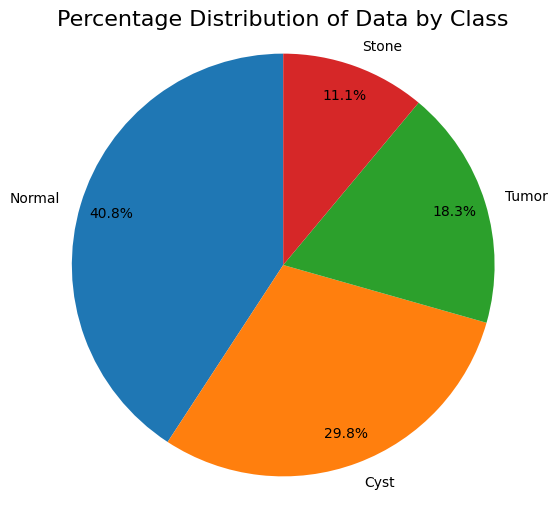

In [4]:
class_counts = df['labels'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
plt.title('Percentage Distribution of Data by Class', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Data Preprocessing

In [5]:
# Division: 70% Train, 30% Remaining (for Val + Test)
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['labels'], random_state=42)
# Division of the Remaining (30%) into two: 15% Val and 15% Test
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['labels'], random_state=42)
# This parameter ensures that the class proportions are the same as in the original data.
print("Train df shape:", train_df.shape)
print("Test df shape:", test_df.shape)
print("Val df shape:", val_df.shape)

Train df shape: (8712, 2)
Test df shape: (1867, 2)
Val df shape: (1867, 2)


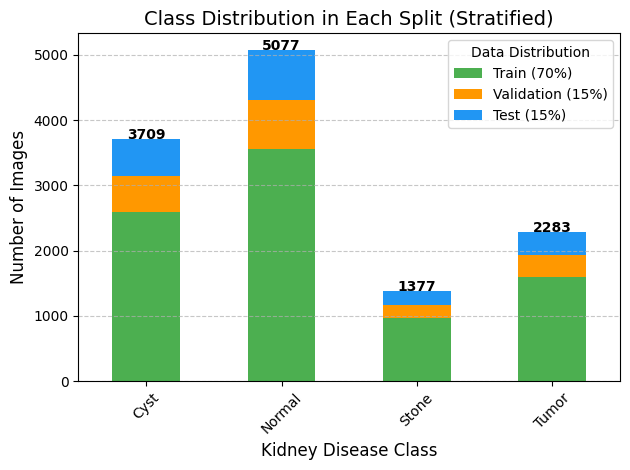

In [6]:
# Count the number of data per class in each split
train_counts = train_df['labels'].value_counts().sort_index()
val_counts = val_df['labels'].value_counts().sort_index()
test_counts = test_df['labels'].value_counts().sort_index()

# Prepare Data for Plotting
# categories = train_counts.index
df_plot = pd.DataFrame({
  "Train (70%)": train_counts,
  "Validation (15%)": val_counts,
  "Test (15%)": test_counts
})

# Creating a Bar Chart
ax = df_plot.plot(kind='bar', stacked=True, color=['#4CAF50', '#FF9800', '#2196F3'])
plt.title("Class Distribution in Each Split (Stratified)", fontsize=14)
plt.xlabel("Kidney Disease Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.legend(title="Data Distribution")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add number labels above each bar
for i, total in enumerate(df_plot.sum(axis=1)):
  ax.text(i, total + 5, int(total), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
# Menampilkan jumlah data per kelas untuk setiap split (Train, Validation, Test)
df_total = df_plot.copy()
df_total["Total"] = df_plot.sum(axis=1)
display(df_total)

,Train (70%),Validation (15%),Test (15%),Total
labels,,,,
Cyst,2596,556,557,3709
Normal,3554,762,761,5077
Stone,964,206,207,1377
Tumor,1598,343,342,2283


# Data Generator (Augmentasi & Loading)

In [8]:
# Hyperparameter that determines the number of training records used in one forward and backward pass of the neural network
batch_size = 64
target_size = (224, 224)

# Instantiate generators of augmented image batches for train generator
train_datagen = ImageDataGenerator(
  # Preprocesses a tensor or Numpy array encoding a batch of images.
  preprocessing_function=keras.applications.inception_resnet_v2.preprocess_input,
  # Rotation_range is a value in degrees (0-180), a range within which to randomly rotate pictures
  rotation_range=20,
  # Are ranges (as a fraction of total width) within which to randomly translate pictures horizontally
  width_shift_range=0.05,
  # Are ranges (as a fraction of total height) within which to randomly translate pictures vertically
  height_shift_range=0.05,
  # Shear makes the image appear 'diagonally cut' so that the model learns to recognize objects from slightly different angles.
  shear_range=0.05,
  # Is for randomly zooming inside pictures
  zoom_range=0.05,
  # Is for randomly flipping half of the images horizontally
  horizontal_flip=True,
  # is the strategy used for filling in newly created pixels
  fill_mode="nearest",
)

# Instantiate generators of augmented image batches for validation generator
val_datagen = ImageDataGenerator(
  preprocessing_function=keras.applications.inception_resnet_v2.preprocess_input
)

# Instantiate generators of augmented image batches for test generator
test_datagen = ImageDataGenerator(
  preprocessing_function=keras.applications.inception_resnet_v2.preprocess_input
)

# Creating a data generator from a dataframe for Training
train_generator = train_datagen.flow_from_dataframe(
  dataframe = train_df, # The main source of image data and labels
  x_col = "filepaths", # The generator will read image files from here
  y_col = "labels", # Used as a target (model output)
  target_size = target_size, # Desired image size
  color_mode = 'rgb', # (3 Color Channels)
  class_mode = "categorical", # Used for multi-class classification
  batch_size = batch_size, # Number of images in 1 batch
  shuffle = True, # Shuffle the data order every epoch
  seed = 42) # Making shuffle results consistent (reproducible)

# Creating a data generator from a dataframe for Validation
validation_generator = val_datagen.flow_from_dataframe(
  dataframe = val_df,
  x_col = "filepaths",
  y_col = "labels",
  target_size = target_size,
  color_mode = 'rgb',
  class_mode = "categorical",
  batch_size = batch_size,
  shuffle = False, # Evaluation becomes fair and reproducible
  seed = 42)

# Creating a data generator from a dataframe for Testing
test_generator = test_datagen.flow_from_dataframe(
  dataframe = test_df,
  x_col = "filepaths",
  y_col = "labels",
  target_size = target_size,
  color_mode = 'rgb',
  class_mode = "categorical",
  batch_size = batch_size,
  shuffle = False, # Evaluation becomes fair and reproducible
  seed = 42)

Found 8712 validated image filenames belonging to 4 classes.
Found 1867 validated image filenames belonging to 4 classes.
Found 1867 validated image filenames belonging to 4 classes.


# Exploratory Data Analysis (EDA)

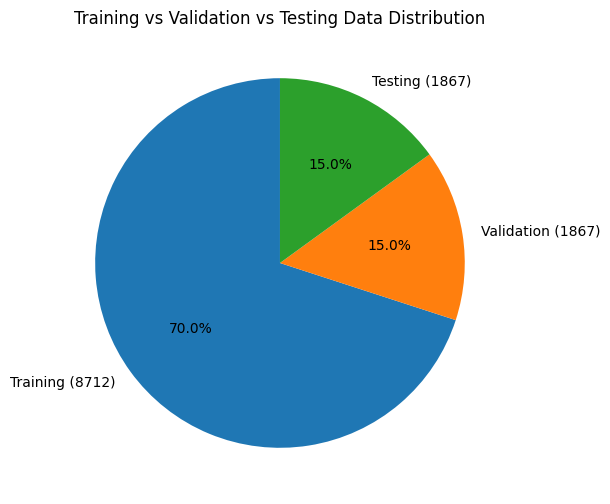

In [9]:
# 1. Get the number of data from the generator
counts = [train_generator.samples, validation_generator.samples, test_generator.samples]
labels = [f'Training ({counts[0]})', f'Validation ({counts[1]})', f'Testing ({counts[2]})']

# 2. Circle plot diagram (Pie Chart)
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Training vs Validation vs Testing Data Distribution")
plt.show()

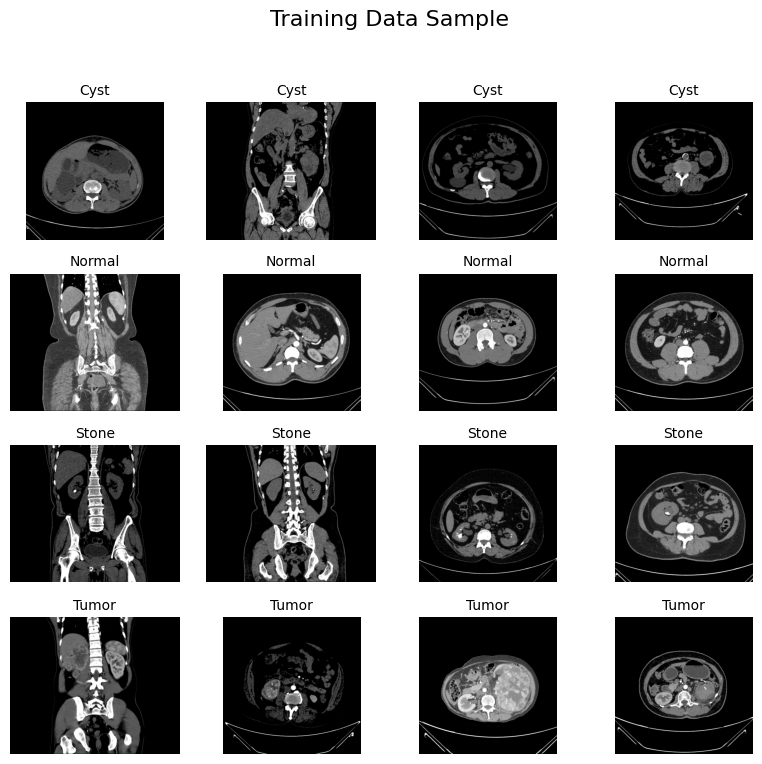

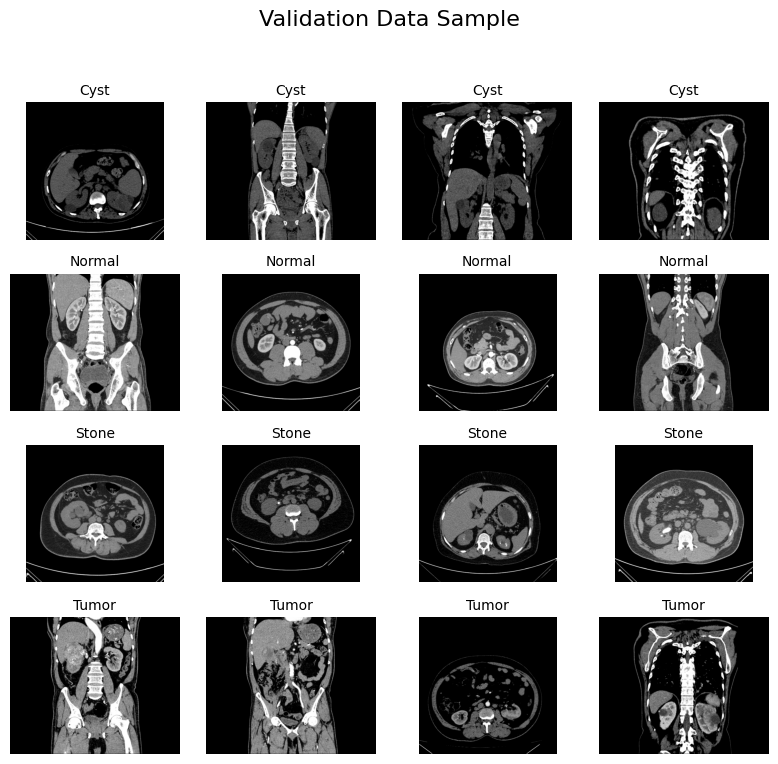

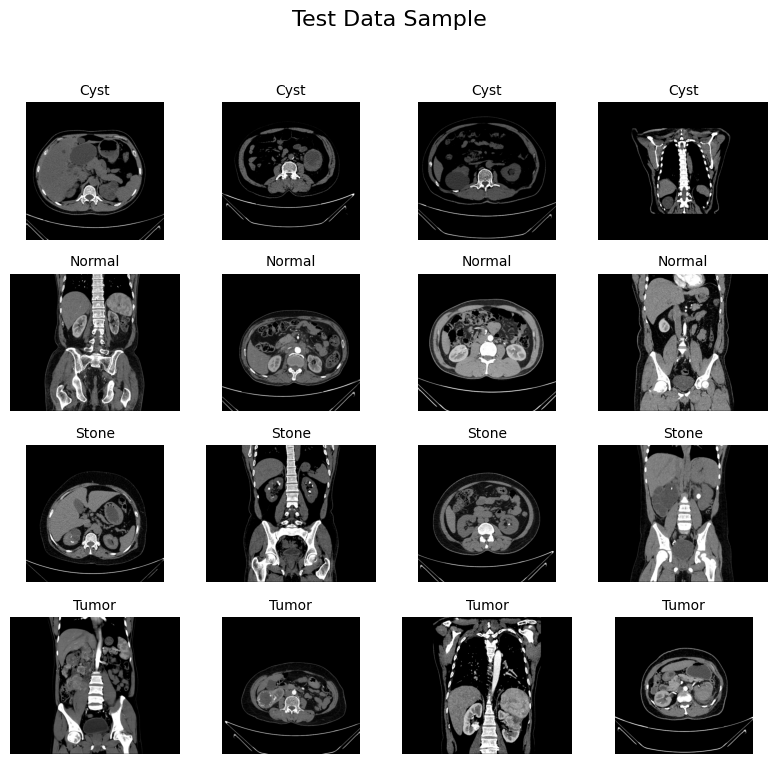

In [10]:
# Displaying sample images from each class in the training, validation, and testing datasets in the form of a visualization grid.
# Define the number of images to display from each class
num_images_per_class = 4

# Get class labels from the train_generator for consistent ordering
class_labels = list(train_generator.class_indices.keys())

# List of dataframes and their titles
datasets = [
  (train_df, "Training Data Sample"),
  (val_df, "Validation Data Sample"),
  (test_df, "Test Data Sample")
]

# Iterating over a dataset collection.
for current_df, title in datasets:
  plt.figure(figsize=(num_images_per_class * 2, len(class_labels) * 2))
  plt.suptitle(title, fontsize=16)

  # Loop for each class
  for i, label in enumerate(class_labels):
    class_filepaths = current_df[current_df['labels'] == label]['filepaths'].values

    # Randomly sample a subset of filepaths if there are enough images
    if len(class_filepaths) > 0:
      sampled_filepaths = np.random.choice(class_filepaths, min(num_images_per_class, len(class_filepaths)), replace=False)
    # If no image is plotted
    else:
      sampled_filepaths = []

    # Plot images
    for j, filepath in enumerate(sampled_filepaths):
      # Calculate subplot position: (number of classes, num_images_per_class, current_row * cols + current_col + 1)
      plt.subplot(len(class_labels), num_images_per_class, i * num_images_per_class + j + 1)
      img = plt.imread(filepath)
      plt.imshow(img)
      plt.title(f"{label}", fontsize=10)
      plt.axis('off')

  plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
  plt.show()

# Model Creation (InceptionResNetV2)

In [11]:
def build_InceptionResNetV2_model():
  # Instantiates the InceptionResNetV2 architecture.
  base_model = keras.applications.InceptionResNetV2(
    # Model menggunakan layer klasifikasi terakhir (fully connected layer) InceptionResNetV2.
    include_top=False,
    # Model menggunakan bobot yang sudah dilatih pada dataset ImageNet.
    weights='imagenet',
    # Menggunakan input tensor yang sudah dibuat sebelumnya.
    input_tensor=None,
    # Ukuran standar untuk banyak CNN.
    input_shape=(224, 224, 3),
    # 4 Class pada data penyakit ginjal
    classes = 4,
    # Softmax digunakan untuk multi-class classification
    classifier_activation='softmax',
  )

  # Mengunci bobot pretrained agar tidak berubah saat training awal
  base_model.trainable = False

  # Menyusun arsitektur model
  model = keras.models.Sequential([
    # Feature extractor dari DenseNet
    base_model,
    # Global average pooling operation untuk 2D data.
    keras.layers.GlobalAveragePooling2D(),
    # Fully connected layer untuk pembelajaran pola penyakit
    keras.layers.Dense(256, activation='relu'),
    # Menstabilkan distribusi aktivasi
    keras.layers.BatchNormalization(),
    # Mengurangi overfitting
    keras.layers.Dropout(0.3),
    # Output layer (4 kelas)
    keras.layers.Dense(4, activation='softmax')  # Normal, Cyst, Tumor, Stone
  ])

  return model

# 2. Panggil fungsi untuk membuat model
InceptionResNetV2_model = build_InceptionResNetV2_model()

# 3. Tampilkan ringkasan arsitektur model
InceptionResNetV2_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_resnet_v2             │ (None, 5, 5, 1536)     │    54,336,736 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_203         │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,732,260 (208.79 MB)

 Trainable params: 395,012 (1.51 MB)

 Non-trainable params: 54,337,248 (207.28 MB)

- Batch size is the number of training examples utilized in one iteration
- Learning rate is the size of the step taken in the optimization algorithm in each iteration.
- Epochs on the other hand are the number of passes of the entire training dataset the machine learning algorithm has completed.

1. Batch Size <br>
Batch size = jumlah data yang diproses sekaligus dalam satu langkah belajar.<br>
Bayangkan kita sedang belajar dari 1 buku berisi 100 soal.<br>
Kalau batch size = 10 → kita belajar 10 soal dulu, lalu update pemahaman.<br>
Kalau batch size = 100 → langsung belajar semua soal sekaligus baru update.<br>
👉 Jadi: <br>
Batch kecil → update lebih sering, tapi lebih “berisik”<br>
Batch besar → lebih stabil, tapi butuh memori lebih besar<br>

2. Learning Rate <br>
Learning rate = seberapa besar langkah saat model memperbaiki kesalahan. <br>
Bayangkan kita lagi mencari jalan ke tujuan: <br>
Learning rate besar → langkahnya jauh-jauh <br>
✔ cepat sampai <br>
❌ tapi bisa “kelewatan” tujuan <br>
Learning rate kecil → langkahnya pelan <br>
✔ lebih akurat <br>
❌ tapi butuh waktu lama <br>
👉 Jadi:
Terlalu besar → tidak stabil (loncat-loncat) <br>
Terlalu kecil → belajar lama <br>

3. Epoch <br>
Epoch = berapa kali seluruh dataset dipelajari ulang dari awal sampai akhir.<br>
Kembali ke contoh 100 soal: <br>
1 epoch → kamu baca semua 100 soal sekali <br>
10 epoch → kamu ulang baca 100 soal itu sebanyak 10 kali <br>
👉 Jadi:
Semakin banyak epoch → model makin belajar <br>
Tapi kalau terlalu banyak → bisa overfitting (hafal, bukan paham) <br>

# Tuning Hyperparameter 1 <br>
Learning Rate = 0.01 <br>
Epochs = 10 <br>

In [ ]:
# Parameter Initialization
learning_rate = 0.01
epochs = 10

# A variant of Adam based on the infinity norm, is a first-order gradient-based optimization method
optimizer = Adamax(learning_rate=learning_rate)
# Configures the model for training.
InceptionResNetV2_model.compile(
  # String (name of optimizer) or optimizer instance
  optimizer=optimizer,
  # Computes the crossentropy loss between the labels and predictions.
  loss='categorical_crossentropy',
  # Calculates how often predictions equal labels.
  metrics=['accuracy'])

# Trains the model for a fixed number of epochs (dataset iterations).
history1 = InceptionResNetV2_model.fit(
  # Objects that provide training data gradually (per batch)
  train_generator,
  # Number of epochs to train the model.
  epochs=epochs,
  # Data on which to evaluate the loss and any model metrics at the end of each epoch.
  validation_data=validation_generator)

Epoch 1/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.7482 - loss: 0.6600 - val_accuracy: 0.8216 - val_loss: 0.4503
Epoch 2/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.8530 - loss: 0.3830 - val_accuracy: 0.8806 - val_loss: 0.3473
Epoch 3/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.8835 - loss: 0.3172 - val_accuracy: 0.8672 - val_loss: 0.3380
Epoch 4/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.8928 - loss: 0.2864 - val_accuracy: 0.8377 - val_loss: 0.3974
Epoch 5/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.9027 - loss: 0.2726 - val_accuracy: 0.9127 - val_loss: 0.2486
Epoch 6/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.9163 - loss: 0.2305 - val_accuracy: 0.8988 - val_loss: 0.2910
Epoch 7/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.9146 - loss: 0.2334 - val_accuracy: 0.8827 - val_loss: 0.3105
Epoch 8/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.9238 - loss: 0.2151 - val_accu

# Evaluation Metric

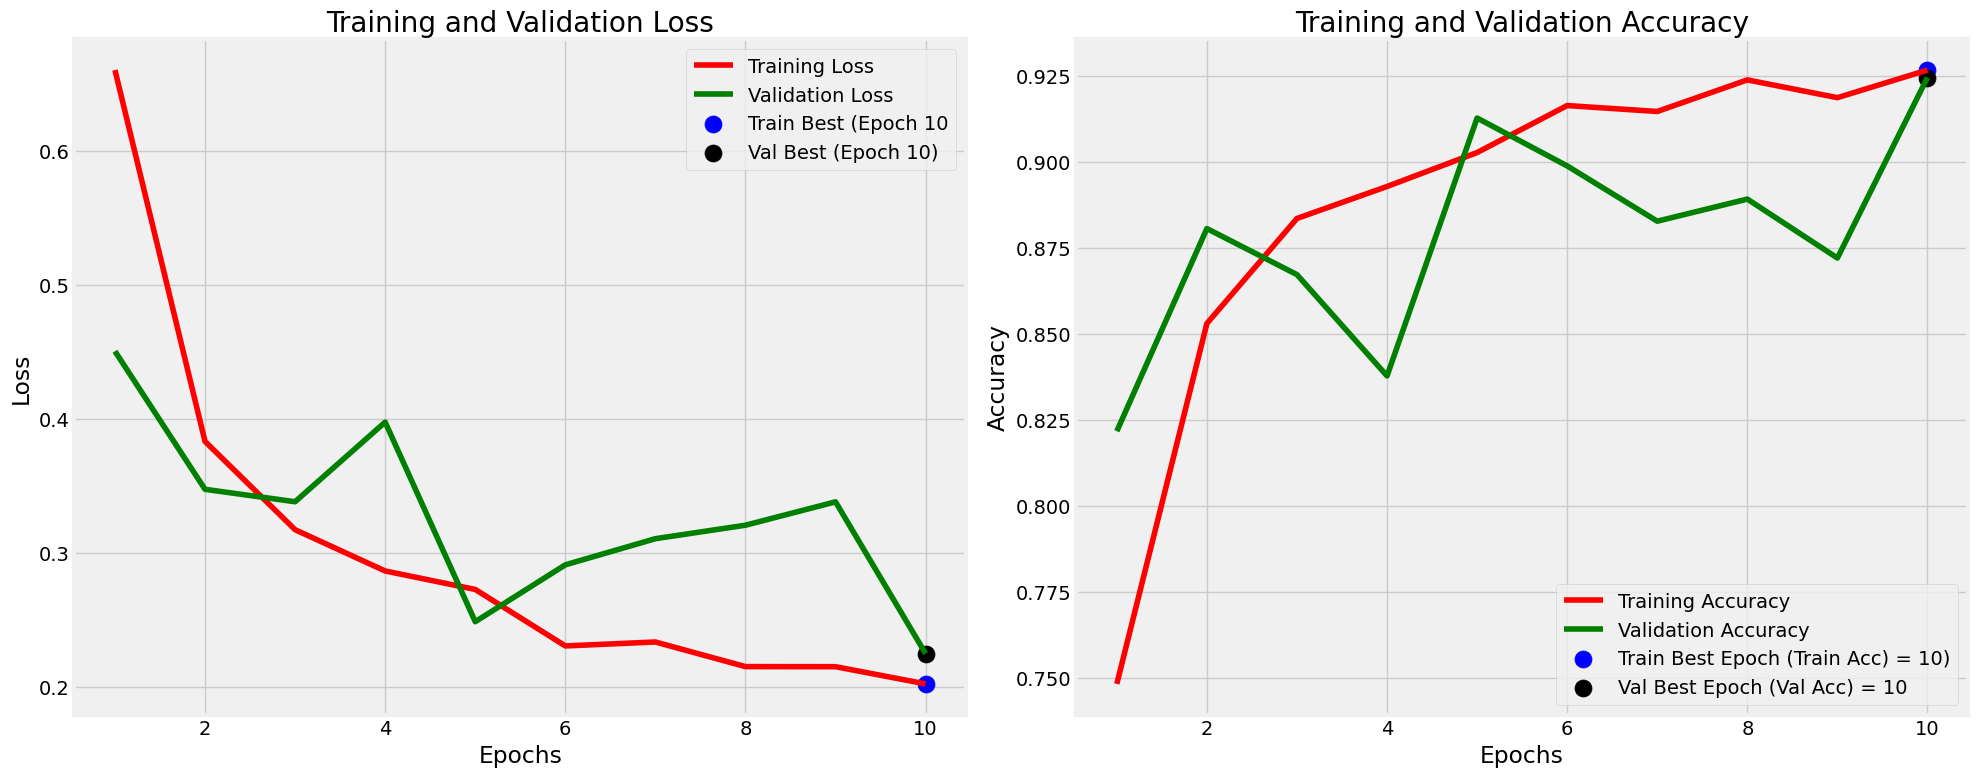

In [ ]:
# Data Extraction from History
train_accuracy = history1.history['accuracy']
train_loss = history1.history['loss']
val_accuracy = history1.history['val_accuracy']
val_loss = history1.history['val_loss']

# Looking for the Best Loss Performance
index_train_loss = np.argmin(train_loss)
train_loss_lowest = train_loss[index_train_loss]
index_val_loss = np.argmin(val_loss)
val_loss_lowest = val_loss[index_val_loss]

# Looking for the Best Accuracy Performance
index_train_accuracy = np.argmax(train_accuracy)
train_accuracy_highest = train_accuracy[index_train_accuracy]
index_val_accuracy = np.argmax(val_accuracy)
val_accuracy_highest = val_accuracy[index_val_accuracy]

# Preparation of Labels and X Axis
Epochs = [i+1 for i in range(len(train_accuracy))]
train_loss_label = f"Train Best (Epoch {index_train_loss+1}"
val_loss_label = f"Val Best (Epoch {index_val_loss+1})"
train_accuracy_label = f"Train Best Epoch (Train Acc) = {index_train_loss+1})"
val_accuracy_label = f"Val Best Epoch (Val Acc) = {index_val_accuracy+1}"

# Visualization
plt.figure(figsize=(20, 8))
plt.style.use('fivethirtyeight')

# Loss Graph
plt.subplot(1, 2, 1)
plt.plot(Epochs, train_loss, 'r', label='Training Loss')
plt.plot(Epochs, val_loss, 'g', label='Validation Loss')

# The best point on the Loss Graph
plt.scatter(index_train_loss+1, train_loss_lowest, s=150, c='blue', label=train_loss_label)
plt.scatter(index_val_loss+1, val_loss_lowest, s=150, c='black', label=val_loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Graph
plt.subplot(1, 2, 2)
plt.plot(Epochs, train_accuracy, 'r', label='Training Accuracy')
plt.plot(Epochs, val_accuracy, 'g', label='Validation Accuracy')

# The best point on the Accuracy Graph
plt.scatter(index_train_accuracy + 1, train_accuracy_highest, s=150, c='blue', label=train_accuracy_label)
plt.scatter(index_val_accuracy + 1, val_accuracy_highest, s=150, c='black', label=val_accuracy_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Reset generator agar prediksi dimulai dari awal dataset
test_generator.reset()

start_time = time.time()
Y_pred = InceptionResNetV2_model.predict(test_generator)
end_time = time.time()

# Waktu Inferensi
inference_time = end_time - start_time
# Prediksi Kelas
y_pred = np.argmax(Y_pred, axis=1)
# Label sebenarnya
y_true = test_generator.classes # Mengambil label asli sesuai urutan folder
test_accuracy = accuracy_score(y_true, y_pred)

print(f"Hyperparameter: ")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}")

# Menambahkan informasi dari history1
print(f"\n--- Informasi dari History 1 ---")
print(f"Best Training Accuracy (History 1): {max(history1.history['accuracy']):.4f} (at Epoch {np.argmax(history1.history['accuracy']) + 1})")
print(f"Best Validation Accuracy (History 1): {max(history1.history['val_accuracy']):.4f} (at Epoch {np.argmax(history1.history['val_accuracy']) + 1})")

print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Total Prediction Time: {inference_time:.2f} seconds")

30/30 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step
Hyperparameter: 
Batch Size: 64
Learning Rate: 0.01
Epoch: 10

--- Informasi dari History 1 ---
Best Training Accuracy (History 1): 0.9267 (at Epoch 10)
Best Validation Accuracy (History 1): 0.9245 (at Epoch 10)
Testing Accuracy: 0.9148
Total Prediction Time: 51.18 seconds


In [ ]:
# Menampilkan Classification Report
# Ini akan menunjukkan Precision, Recall, dan F1-Score untuk setiap jenis penyakit ginjal
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
# Menambahkan parameter digits=3 untuk menampilkan 3 angka di belakang koma
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)


--- Classification Report ---
              precision    recall  f1-score   support

        Cyst      0.930     0.975     0.952       557
      Normal      0.905     0.966     0.935       761
       Stone      0.822     0.850     0.836       207
       Tumor      0.988     0.743     0.848       342

    accuracy                          0.915      1867
   macro avg      0.911     0.883     0.893      1867
weighted avg      0.919     0.915     0.913      1867




--- Confusion Matrix ---


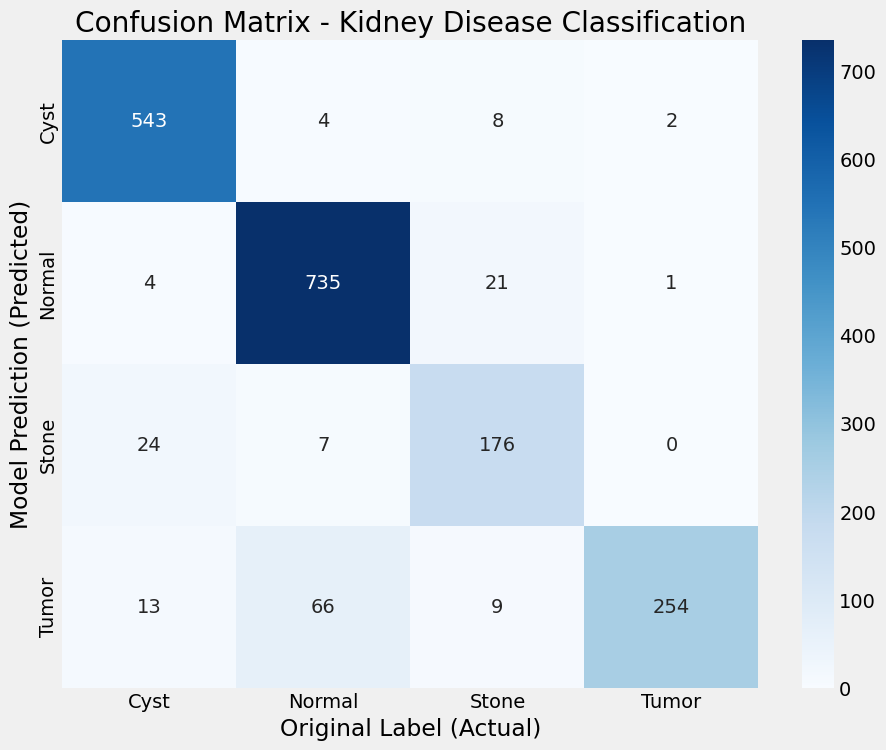

In [ ]:
# Membuat Confusion Matrix (Visual)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Kidney Disease Classification')
plt.xlabel('Original Label (Actual)')
plt.ylabel('Model Prediction (Predicted)')
plt.show()

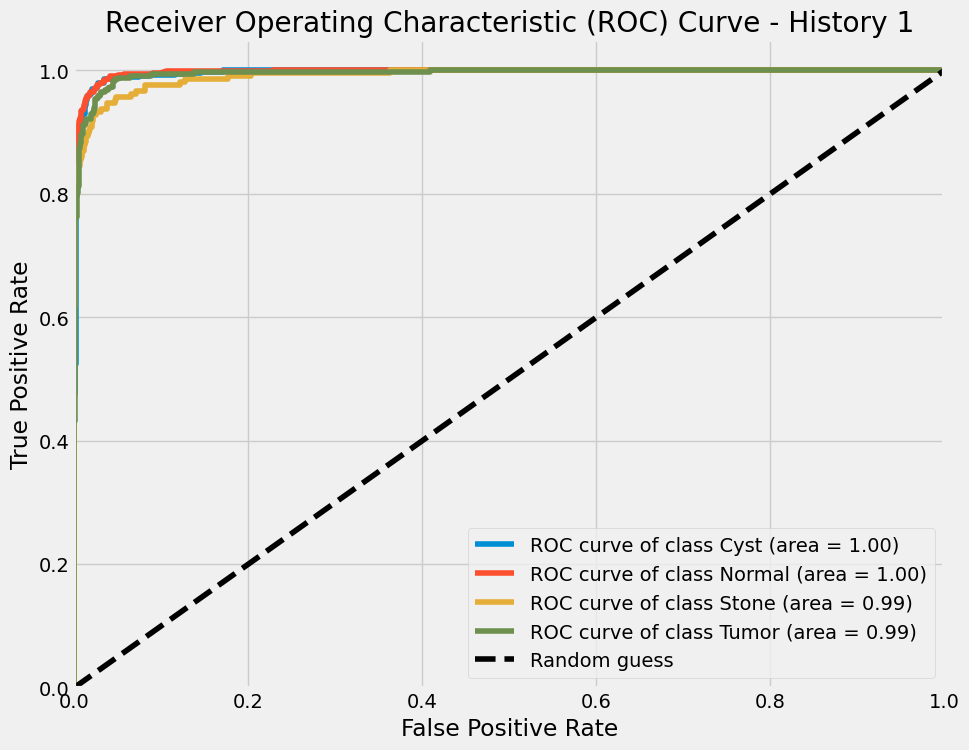

In [ ]:
# Assuming Y_pred and y_true not already calculated for the test set
Y_pred = InceptionResNetV2_model.predict(test_generator)
y_true = test_generator.classes

# Convert y_true to one-hot encoding for ROC AUC calculation
label_binarizer = LabelBinarizer()
y_true_onehot = label_binarizer.fit_transform(y_true)

n_classes = len(class_labels)

# Plotting ROC curves
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], Y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve of class {class_labels[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - History 1')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Tuning Hyperparameter 2
learning_rate = 0.01 <br>
epoch = 20 <br>

In [ ]:
# Inisialisasi Parameter
learning_rate = 0.01
epochs = 20

optimizer = Adamax(learning_rate=learning_rate)
InceptionResNetV2_model.compile(
  optimizer=optimizer,
  loss='categorical_crossentropy',
  metrics=['accuracy'])

history2 = InceptionResNetV2_model.fit(
  train_generator,
  epochs=epochs,
  validation_data=validation_generator)

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - accuracy: 0.9025 - loss: 0.2755 - val_accuracy: 0.8532 - val_loss: 0.3875
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.9191 - loss: 0.2177 - val_accuracy: 0.8157 - val_loss: 0.5223
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.9264 - loss: 0.2081 - val_accuracy: 0.9320 - val_loss: 0.1905
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.9271 - loss: 0.1978 - val_accuracy: 0.8881 - val_loss: 0.2970
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.9347 - loss: 0.1784 - val_accuracy: 0.9111 - val_loss: 0.2284
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.9345 - loss: 0.1793 - val_accuracy: 0.8329 - val_loss: 0.5361
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.9348 - loss: 0.1820 - val_accuracy: 0.9175 - val_loss: 0.2330
Epoch 8/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.9339 - loss: 0.1840 - val_accu

# Evaluation Metric

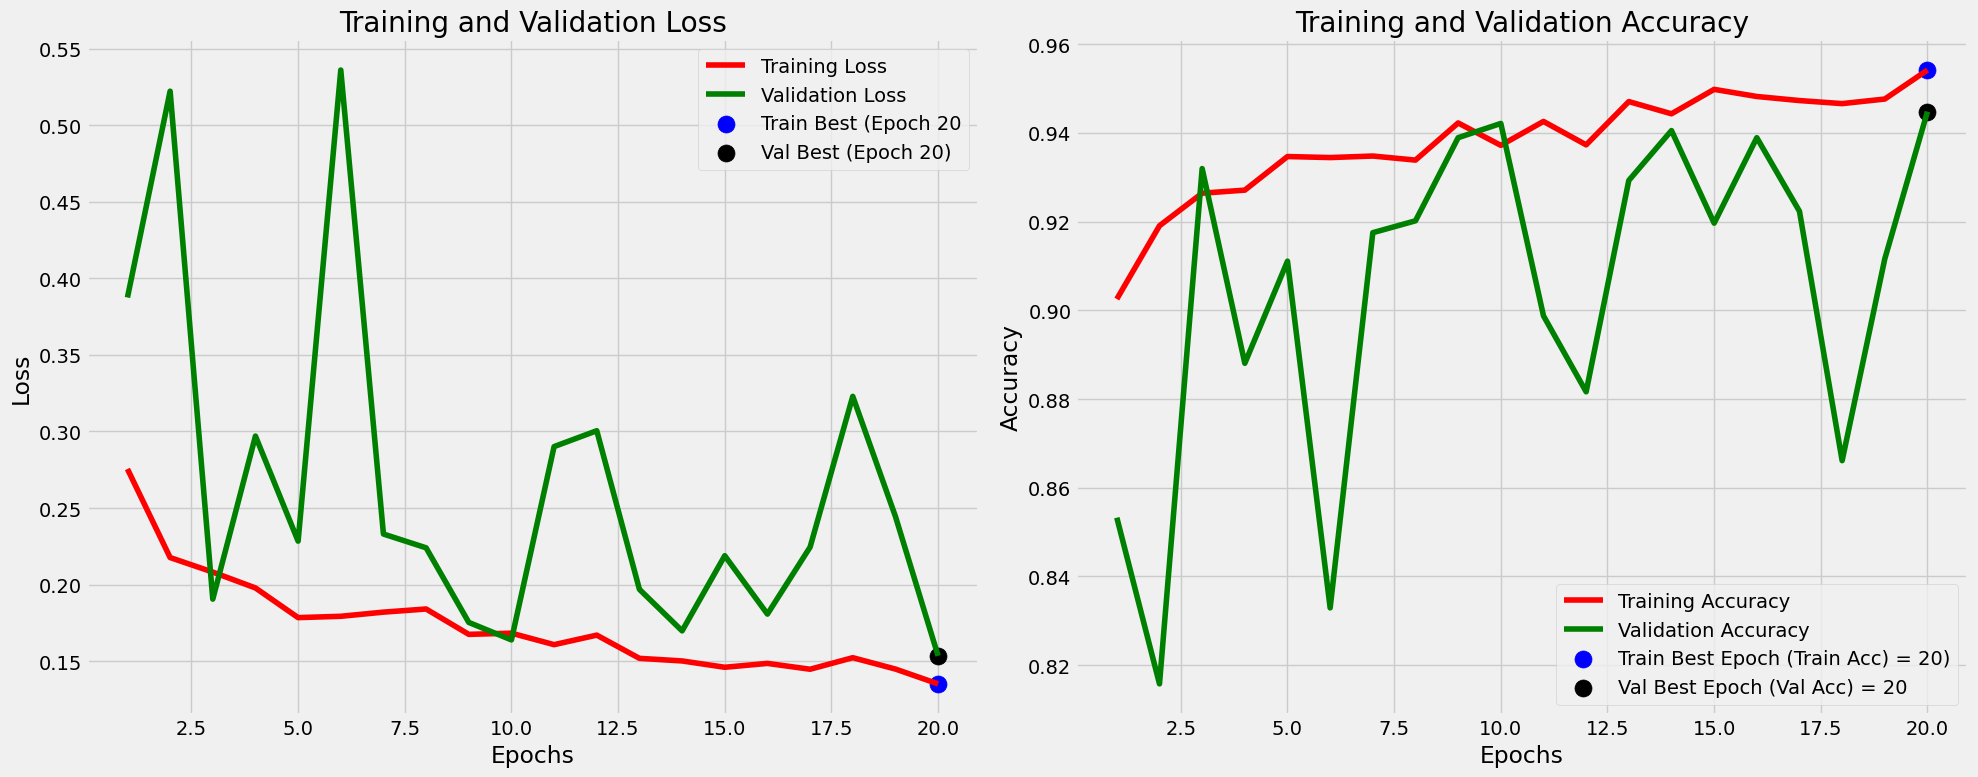

In [ ]:
# Ekstraksi Data dari History
train_accuracy = history2.history['accuracy']
train_loss = history2.history['loss']
val_accuracy = history2.history['val_accuracy']
val_loss = history2.history['val_loss']

# Mencari Titik Performa Terbaik
# Loss (semakin kecil semakin baik)
index_train_loss = np.argmin(train_loss)
train_loss_lowest = train_loss[index_train_loss]
index_val_loss = np.argmin(val_loss)
val_loss_lowest = val_loss[index_val_loss]

# Accuracy (semakin besar semakin baik)
index_train_accuracy = np.argmax(train_accuracy)
train_accuracy_highest = train_accuracy[index_train_accuracy]
index_val_accuracy = np.argmax(val_accuracy)
val_accuracy_highest = val_accuracy[index_val_accuracy]

# Penyiapan Label dan Sumbu X
Epochs = [i+1 for i in range(len(train_accuracy))]

train_loss_label = f"Train Best (Epoch {index_train_loss+1}"
val_loss_label = f"Val Best (Epoch {index_val_loss+1})"

train_accuracy_label = f"Train Best Epoch (Train Acc) = {index_train_loss+1})"
val_accuracy_label = f"Val Best Epoch (Val Acc) = {index_val_accuracy+1}"

# Visualisasi
plt.figure(figsize=(20, 8))
plt.style.use('fivethirtyeight')

# Grafik Loss
plt.subplot(1, 2, 1)
plt.plot(Epochs, train_loss, 'r', label='Training Loss')
plt.plot(Epochs, val_loss, 'g', label='Validation Loss')

# Titik terbaik
plt.scatter(index_train_loss+1, train_loss_lowest, s=150, c='blue', label=train_loss_label)
plt.scatter(index_val_loss+1, val_loss_lowest, s=150, c='black', label=val_loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Grafik Accuracy
plt.subplot(1, 2, 2)
plt.plot(Epochs, train_accuracy, 'r', label='Training Accuracy')
plt.plot(Epochs, val_accuracy, 'g', label='Validation Accuracy')

# Titik terbaik
plt.scatter(index_train_accuracy + 1, train_accuracy_highest, s=150, c='blue', label=train_accuracy_label)
plt.scatter(index_val_accuracy + 1, val_accuracy_highest, s=150, c='black', label=val_accuracy_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Reset generator agar prediksi dimulai dari awal dataset
test_generator.reset()

start_time = time.time()
Y_pred = InceptionResNetV2_model.predict(test_generator)
end_time = time.time()

# Waktu Inferensi
inference_time = end_time - start_time
# Prediksi Kelas
y_pred = np.argmax(Y_pred, axis=1)
# Label sebenarnya
y_true = test_generator.classes # Mengambil label asli sesuai urutan folder
test_accuracy = accuracy_score(y_true, y_pred)

print(f"Hyperparameter: ")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}")

# Menambahkan informasi dari history1
print(f"\n--- Informasi dari History 2 ---")
print(f"Best Training Accuracy (History 2): {train_accuracy_highest:.4f} (at Epoch {index_train_accuracy + 1})")
print(f"Best Validation Accuracy (History 2): {val_accuracy_highest:.4f} (at Epoch {index_val_accuracy + 1})")

print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Total Prediction Time: {inference_time:.2f} seconds")

30/30 ━━━━━━━━━━━━━━━━━━━━ 35s 780ms/step
Hyperparameter: 
Batch Size: 64
Learning Rate: 0.01
Epoch: 20

--- Informasi dari History 2 ---
Best Training Accuracy (History 2): 0.9542 (at Epoch 20)
Best Validation Accuracy (History 2): 0.9448 (at Epoch 20)
Testing Accuracy: 0.9357
Total Prediction Time: 36.00 seconds


In [ ]:
# Menampilkan Classification Report
# Ini akan menunjukkan Precision, Recall, dan F1-Score untuk setiap jenis penyakit ginjal
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
# Menambahkan parameter digits=3 untuk menampilkan 3 angka di belakang koma
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)


--- Classification Report ---
              precision    recall  f1-score   support

        Cyst      0.966     0.955     0.960       557
      Normal      0.898     0.993     0.943       761
       Stone      0.961     0.826     0.888       207
       Tumor      0.973     0.842     0.903       342

    accuracy                          0.936      1867
   macro avg      0.949     0.904     0.924      1867
weighted avg      0.939     0.936     0.935      1867




--- Confusion Matrix ---


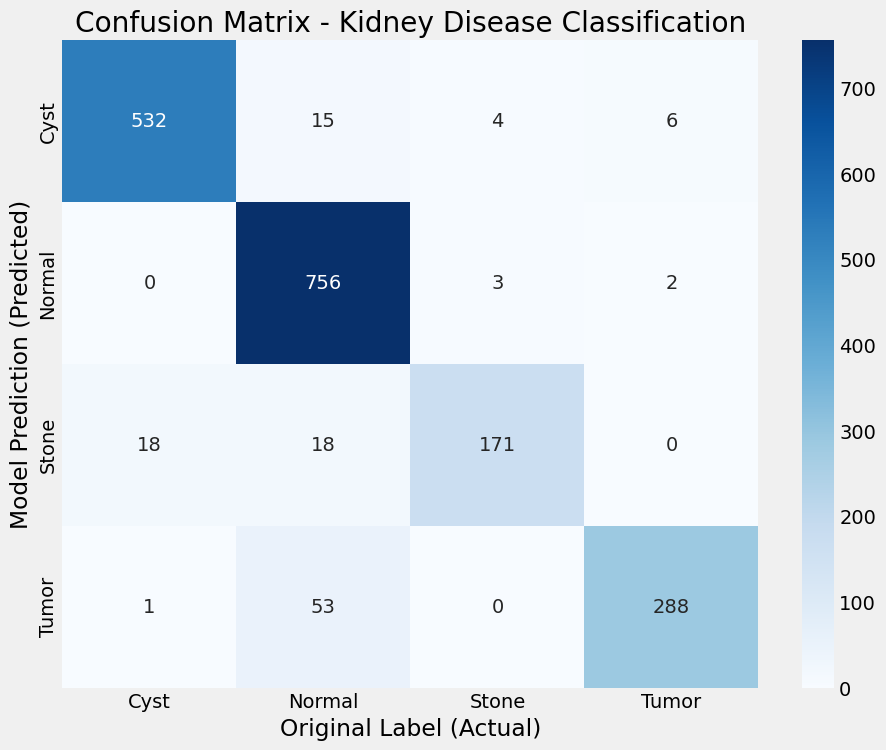

In [ ]:
# Membuat Confusion Matrix (Visual)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Kidney Disease Classification')
plt.xlabel('Original Label (Actual)')
plt.ylabel('Model Prediction (Predicted)')
plt.show()

# Tuning Hyperparameter 3
learning_rate = 0.001 <br>
epoch = 20 <br>

In [12]:
# Inisialisasi Parameter
learning_rate = 0.001
epochs = 20

optimizer = Adamax(learning_rate=learning_rate)
InceptionResNetV2_model.compile(
  optimizer=optimizer,
  loss='categorical_crossentropy',
  metrics=['accuracy'])

history3 = InceptionResNetV2_model.fit(
  train_generator,
  epochs=epochs,
  validation_data=validation_generator)

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 273s 2s/step - accuracy: 0.7606 - loss: 0.6339 - val_accuracy: 0.8152 - val_loss: 0.4908
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.8588 - loss: 0.3801 - val_accuracy: 0.8822 - val_loss: 0.3335
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.8853 - loss: 0.3144 - val_accuracy: 0.8897 - val_loss: 0.2991
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.9034 - loss: 0.2660 - val_accuracy: 0.8966 - val_loss: 0.2740
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.9113 - loss: 0.2491 - val_accuracy: 0.9089 - val_loss: 0.2533
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.9187 - loss: 0.2274 - val_accuracy: 0.9255 - val_loss: 0.2228
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.9229 - loss: 0.2161 - val_accuracy: 0.8961 - val_loss: 0.2740
Epoch 8/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.9261 - loss: 0.2072 - val_accu

# Evaluation Metric

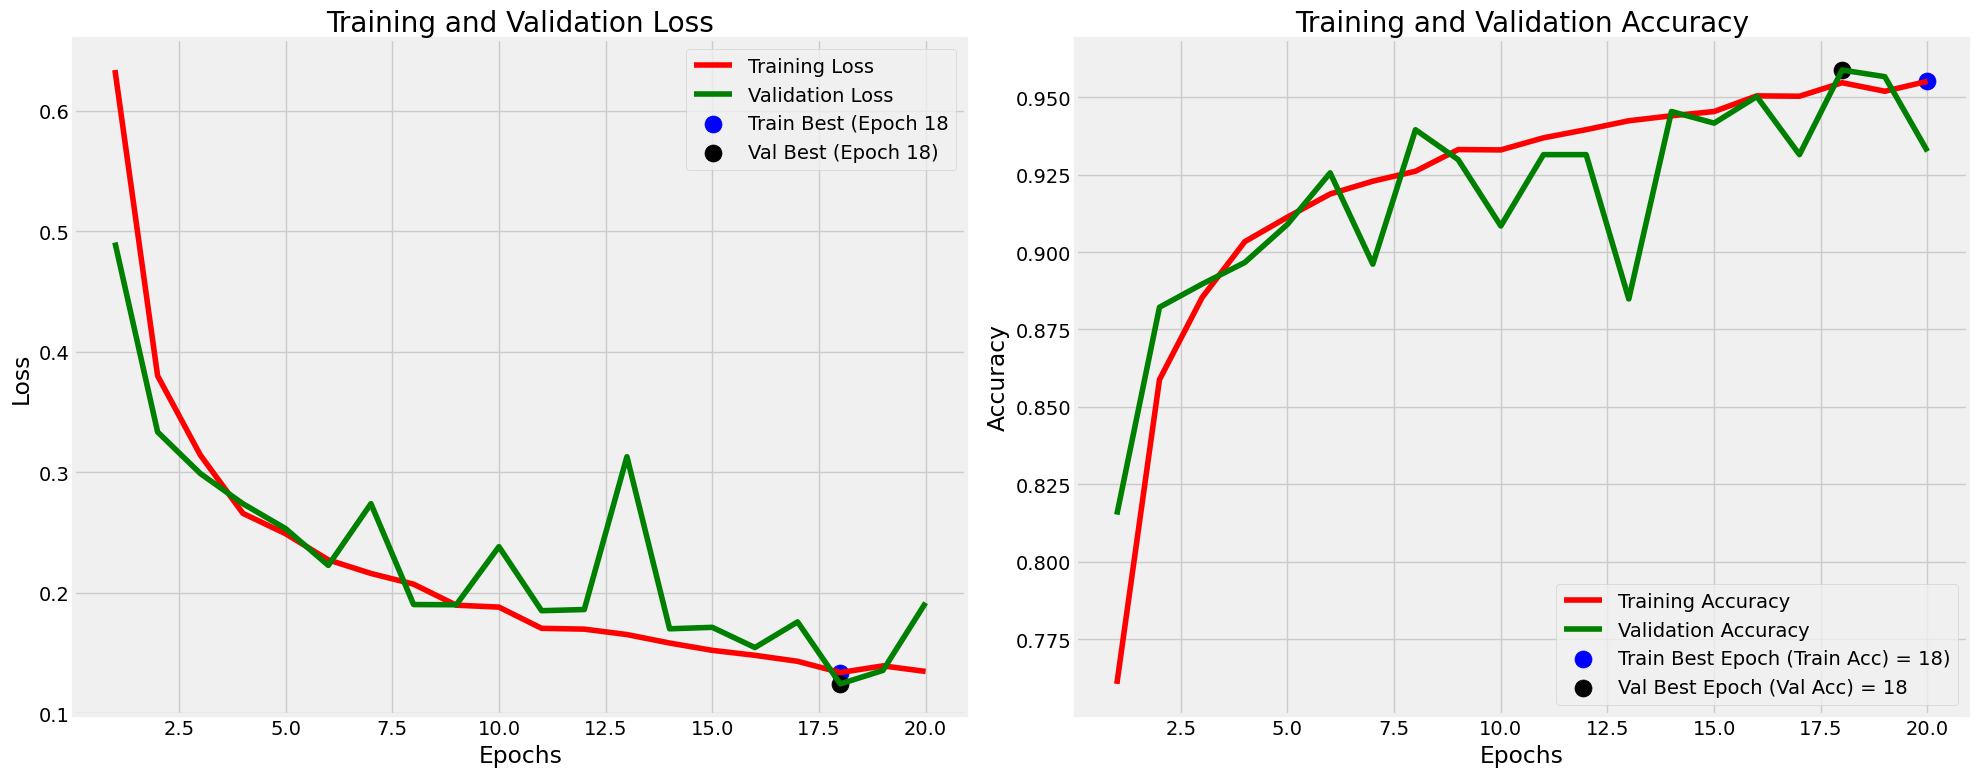

In [13]:
# Ekstraksi Data dari History
train_accuracy = history3.history['accuracy']
train_loss = history3.history['loss']
val_accuracy = history3.history['val_accuracy']
val_loss = history3.history['val_loss']

# Mencari Titik Performa Terbaik
# Loss (semakin kecil semakin baik)
index_train_loss = np.argmin(train_loss)
train_loss_lowest = train_loss[index_train_loss]
index_val_loss = np.argmin(val_loss)
val_loss_lowest = val_loss[index_val_loss]

# Accuracy (semakin besar semakin baik)
index_train_accuracy = np.argmax(train_accuracy)
train_accuracy_highest = train_accuracy[index_train_accuracy]
index_val_accuracy = np.argmax(val_accuracy)
val_accuracy_highest = val_accuracy[index_val_accuracy]

# Penyiapan Label dan Sumbu X
Epochs = [i+1 for i in range(len(train_accuracy))]

train_loss_label = f"Train Best (Epoch {index_train_loss+1}"
val_loss_label = f"Val Best (Epoch {index_val_loss+1})"

train_accuracy_label = f"Train Best Epoch (Train Acc) = {index_train_loss+1})"
val_accuracy_label = f"Val Best Epoch (Val Acc) = {index_val_accuracy+1}"

# Visualisasi
plt.figure(figsize=(20, 8))
plt.style.use('fivethirtyeight')

# Grafik Loss
plt.subplot(1, 2, 1)
plt.plot(Epochs, train_loss, 'r', label='Training Loss')
plt.plot(Epochs, val_loss, 'g', label='Validation Loss')

# Titik terbaik
plt.scatter(index_train_loss+1, train_loss_lowest, s=150, c='blue', label=train_loss_label)
plt.scatter(index_val_loss+1, val_loss_lowest, s=150, c='black', label=val_loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Grafik Accuracy
plt.subplot(1, 2, 2)
plt.plot(Epochs, train_accuracy, 'r', label='Training Accuracy')
plt.plot(Epochs, val_accuracy, 'g', label='Validation Accuracy')

# Titik terbaik
plt.scatter(index_train_accuracy + 1, train_accuracy_highest, s=150, c='blue', label=train_accuracy_label)
plt.scatter(index_val_accuracy + 1, val_accuracy_highest, s=150, c='black', label=val_accuracy_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
# Reset generator agar prediksi dimulai dari awal dataset
test_generator.reset()

start_time = time.time()
Y_pred = InceptionResNetV2_model.predict(test_generator)
end_time = time.time()

# Waktu Inferensi
inference_time = end_time - start_time
# Prediksi Kelas
y_pred = np.argmax(Y_pred, axis=1)
# Label sebenarnya
y_true = test_generator.classes # Mengambil label asli sesuai urutan folder
test_accuracy = accuracy_score(y_true, y_pred)

print(f"Hyperparameter: ")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}")

# Menambahkan informasi dari history3
print(f"\n--- Informasi dari History 3 ---")
print(f"Best Training Accuracy (History 3): {train_accuracy_highest:.4f} (at Epoch {index_train_accuracy + 1})")
print(f"Best Validation Accuracy (History 3): {val_accuracy_highest:.4f} (at Epoch {index_val_accuracy + 1})")

print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Total Prediction Time: {inference_time:.2f} seconds")

30/30 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step
Hyperparameter: 
Batch Size: 64
Learning Rate: 0.001
Epoch: 20

--- Informasi dari History 3 ---
Best Training Accuracy (History 3): 0.9551 (at Epoch 20)
Best Validation Accuracy (History 3): 0.9588 (at Epoch 18)
Testing Accuracy: 0.9207
Total Prediction Time: 83.77 seconds


In [15]:
# Menampilkan Classification Report
# Ini akan menunjukkan Precision, Recall, dan F1-Score untuk setiap jenis penyakit ginjal
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
# Menambahkan parameter digits=3 untuk menampilkan 3 angka di belakang koma
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)


--- Classification Report ---
              precision    recall  f1-score   support

        Cyst      0.948     0.975     0.961       557
      Normal      0.984     0.883     0.931       761
       Stone      0.711     0.937     0.808       207
       Tumor      0.917     0.906     0.912       342

    accuracy                          0.921      1867
   macro avg      0.890     0.925     0.903      1867
weighted avg      0.931     0.921     0.923      1867




--- Confusion Matrix ---


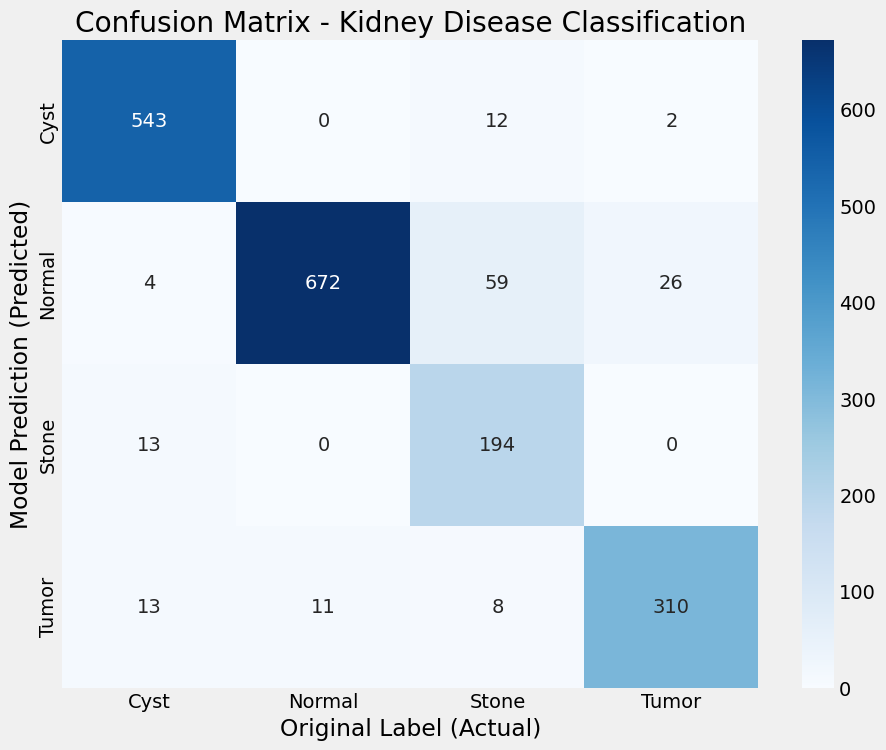

In [16]:
# Membuat Confusion Matrix (Visual)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Kidney Disease Classification')
plt.xlabel('Original Label (Actual)')
plt.ylabel('Model Prediction (Predicted)')
plt.show()

30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 382ms/step


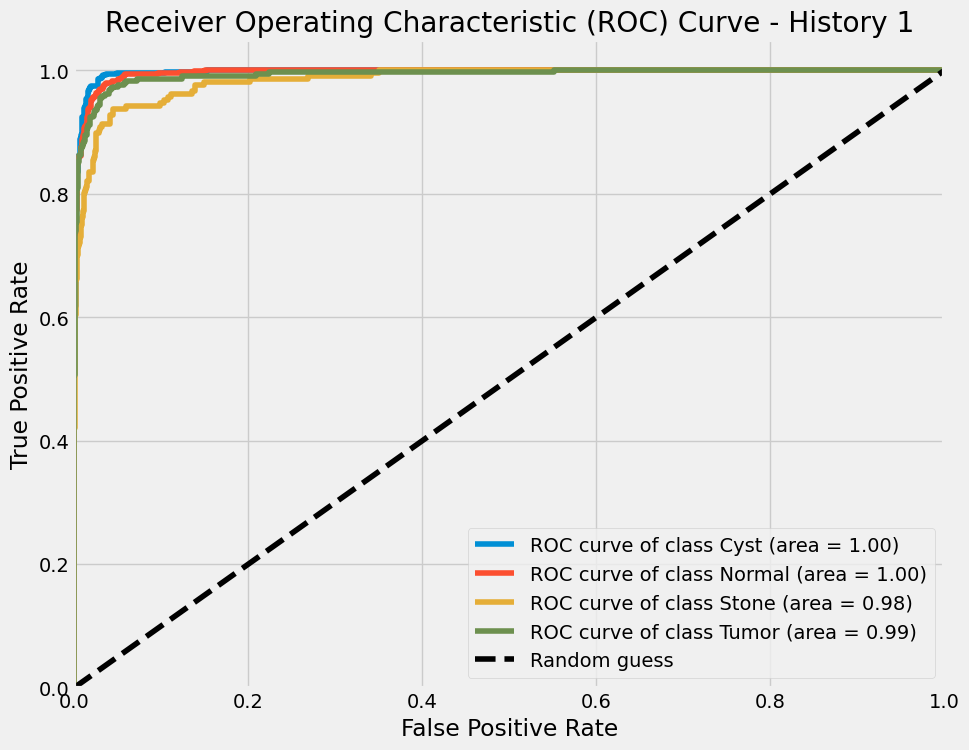

In [17]:
# Assuming Y_pred and y_true not already calculated for the test set
Y_pred = InceptionResNetV2_model.predict(test_generator)
y_true = test_generator.classes

# Convert y_true to one-hot encoding for ROC AUC calculation
label_binarizer = LabelBinarizer()
y_true_onehot = label_binarizer.fit_transform(y_true)

n_classes = len(class_labels)

# Plotting ROC curves
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], Y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve of class {class_labels[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - History 1')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Tuning Hyperparameter 4
learning_rate = 0.0001 <br>
epochs = 20 <br>

In [18]:
# Parameter Initialization
learning_rate = 0.0001
epochs = 20

# A variant of Adam based on the infinity norm, is a first-order gradient-based optimization method
optimizer = Adamax(learning_rate=learning_rate)
# Configures the model for training.
InceptionResNetV2_model.compile(
  # String (name of optimizer) or optimizer instance
  optimizer=optimizer,
  # Computes the crossentropy loss between the labels and predictions.
  loss='categorical_crossentropy',
  # Calculates how often predictions equal labels.
  metrics=['accuracy'])

# Trains the model for a fixed number of epochs (dataset iterations).
history4 = InceptionResNetV2_model.fit(
  # Objects that provide training data gradually (per batch)
  train_generator,
  # Number of epochs to train the model.
  epochs=epochs,
  # Data on which to evaluate the loss and any model metrics at the end of each epoch.
  validation_data=validation_generator)

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.9599 - loss: 0.1166 - val_accuracy: 0.9689 - val_loss: 0.1030
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.9646 - loss: 0.1081 - val_accuracy: 0.9652 - val_loss: 0.0999
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.9651 - loss: 0.1040 - val_accuracy: 0.9738 - val_loss: 0.0888
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.9668 - loss: 0.0983 - val_accuracy: 0.9759 - val_loss: 0.0869
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.9679 - loss: 0.0973 - val_accuracy: 0.9770 - val_loss: 0.0862
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.9718 - loss: 0.0915 - val_accuracy: 0.9775 - val_loss: 0.0840
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.9665 - loss: 0.0997 - val_accuracy: 0.9716 - val_loss: 0.0922
Epoch 8/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.9679 - loss: 0.0968 - val_accu

# Evaluation Metric

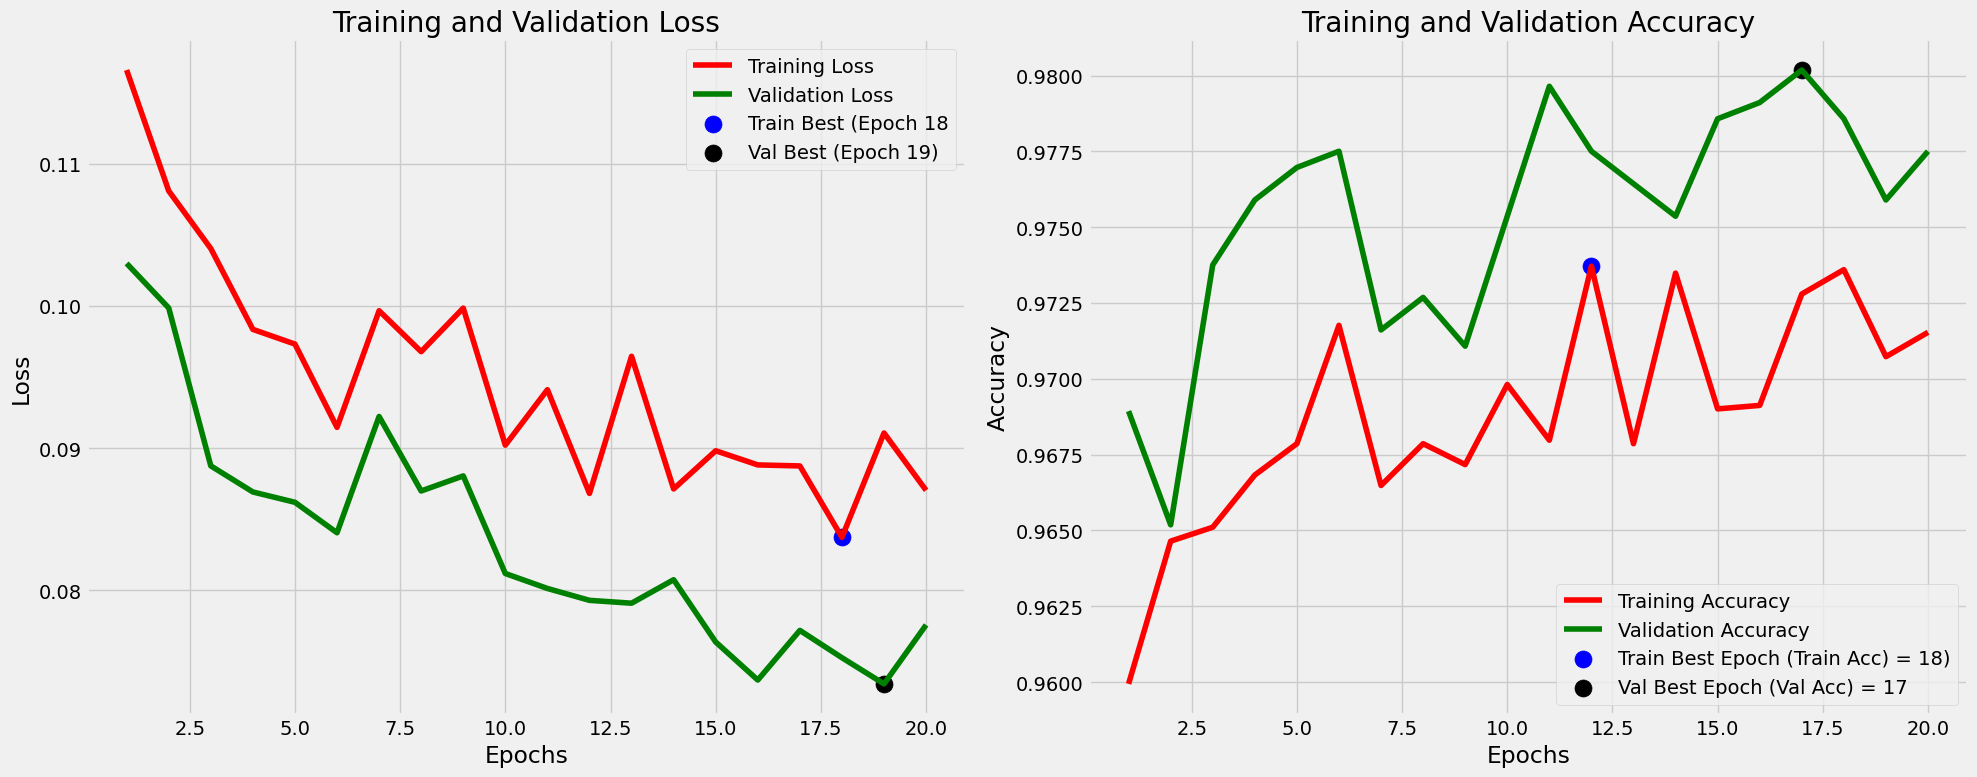

In [19]:
# Ekstraksi Data dari History
train_accuracy = history4.history['accuracy']
train_loss = history4.history['loss']
val_accuracy = history4.history['val_accuracy']
val_loss = history4.history['val_loss']

# Mencari Titik Performa Terbaik
# Loss (semakin kecil semakin baik)
index_train_loss = np.argmin(train_loss)
train_loss_lowest = train_loss[index_train_loss]
index_val_loss = np.argmin(val_loss)
val_loss_lowest = val_loss[index_val_loss]

# Accuracy (semakin besar semakin baik)
index_train_accuracy = np.argmax(train_accuracy)
train_accuracy_highest = train_accuracy[index_train_accuracy]
index_val_accuracy = np.argmax(val_accuracy)
val_accuracy_highest = val_accuracy[index_val_accuracy]

# Penyiapan Label dan Sumbu X
Epochs = [i+1 for i in range(len(train_accuracy))]
train_loss_label = f"Train Best (Epoch {index_train_loss+1}"
val_loss_label = f"Val Best (Epoch {index_val_loss+1})"
train_accuracy_label = f"Train Best Epoch (Train Acc) = {index_train_loss+1})"
val_accuracy_label = f"Val Best Epoch (Val Acc) = {index_val_accuracy+1}"

# Visualisasi
plt.figure(figsize=(20, 8))
plt.style.use('fivethirtyeight')

# Grafik Loss
plt.subplot(1, 2, 1)
plt.plot(Epochs, train_loss, 'r', label='Training Loss')
plt.plot(Epochs, val_loss, 'g', label='Validation Loss')

# Titik terbaik
plt.scatter(index_train_loss+1, train_loss_lowest, s=150, c='blue', label=train_loss_label)
plt.scatter(index_val_loss+1, val_loss_lowest, s=150, c='black', label=val_loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Grafik Accuracy
plt.subplot(1, 2, 2)
plt.plot(Epochs, train_accuracy, 'r', label='Training Accuracy')
plt.plot(Epochs, val_accuracy, 'g', label='Validation Accuracy')

# Titik terbaik
plt.scatter(index_train_accuracy + 1, train_accuracy_highest, s=150, c='blue', label=train_accuracy_label)
plt.scatter(index_val_accuracy + 1, val_accuracy_highest, s=150, c='black', label=val_accuracy_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
# Reset generator agar prediksi dimulai dari awal dataset
test_generator.reset()

start_time = time.time()
Y_pred = InceptionResNetV2_model.predict(test_generator)
end_time = time.time()

# Waktu Inferensi
inference_time = end_time - start_time
# Prediksi Kelas
y_pred = np.argmax(Y_pred, axis=1)
# Label sebenarnya
y_true = test_generator.classes # Mengambil label asli sesuai urutan folder
test_accuracy = accuracy_score(y_true, y_pred)

print(f"Hyperparameter: ")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}")

# Menambahkan informasi dari history1
print(f"\n--- Informasi dari History 4 ---")
print(f"Best Training Accuracy (History 4): {train_accuracy_highest:.4f} (at Epoch {index_train_accuracy + 1})")
print(f"Best Validation Accuracy (History 4): {val_accuracy_highest:.4f} (at Epoch {index_val_accuracy + 1})")

print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Total Prediction Time: {inference_time:.2f} seconds")

30/30 ━━━━━━━━━━━━━━━━━━━━ 37s 845ms/step
Hyperparameter: 
Batch Size: 64
Learning Rate: 0.0001
Epoch: 20

--- Informasi dari History 4 ---
Best Training Accuracy (History 4): 0.9737 (at Epoch 12)
Best Validation Accuracy (History 4): 0.9802 (at Epoch 17)
Testing Accuracy: 0.9652
Total Prediction Time: 37.97 seconds


In [21]:
# Menampilkan Classification Report
# Ini akan menunjukkan Precision, Recall, dan F1-Score untuk setiap jenis penyakit ginjal
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
# Menambahkan parameter digits=3 untuk menampilkan 3 angka di belakang koma
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)


--- Classification Report ---
              precision    recall  f1-score   support

        Cyst      0.961     0.984     0.972       557
      Normal      0.985     0.971     0.978       761
       Stone      0.882     0.903     0.893       207
       Tumor      0.979     0.959     0.969       342

    accuracy                          0.965      1867
   macro avg      0.952     0.954     0.953      1867
weighted avg      0.966     0.965     0.965      1867




--- Confusion Matrix ---


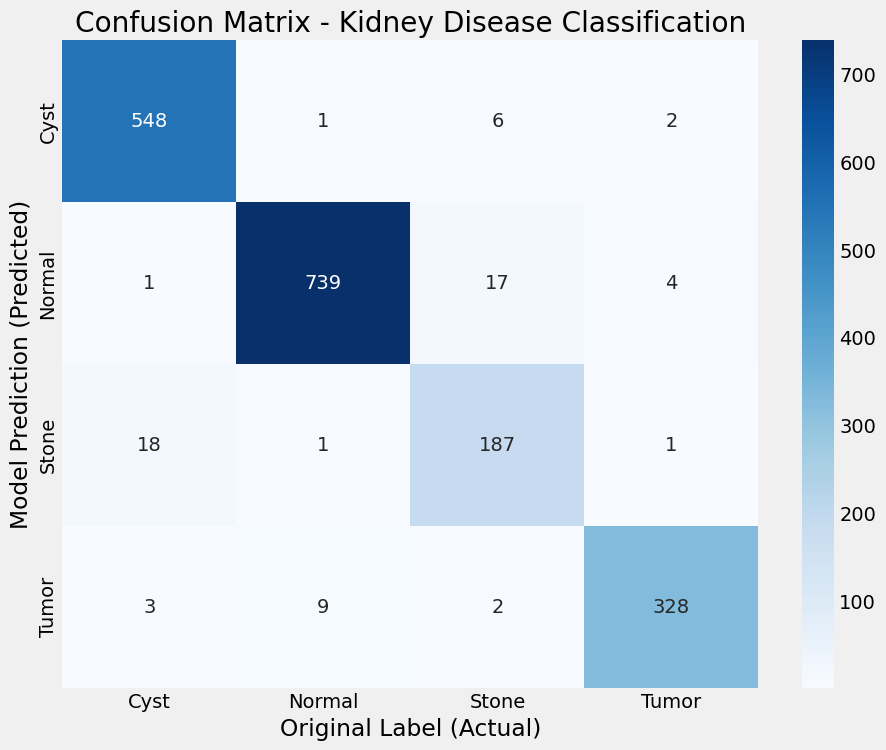

In [22]:
# Membuat Confusion Matrix (Visual)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Kidney Disease Classification')
plt.xlabel('Original Label (Actual)')
plt.ylabel('Model Prediction (Predicted)')
plt.show()

# Prediction on New Image (InceptionResNetV2)


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Image path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst/Cyst- (1).jpg
Predicted class: Cyst
Confidence: 99.99%

All class probabilities:
  Cyst: 99.99%
  Normal: 0.00%
  Stone: 0.01%
  Tumor: 0.00%
Using output of base model 'inception_resnet_v2' for Grad-CAM with 1536 channels.


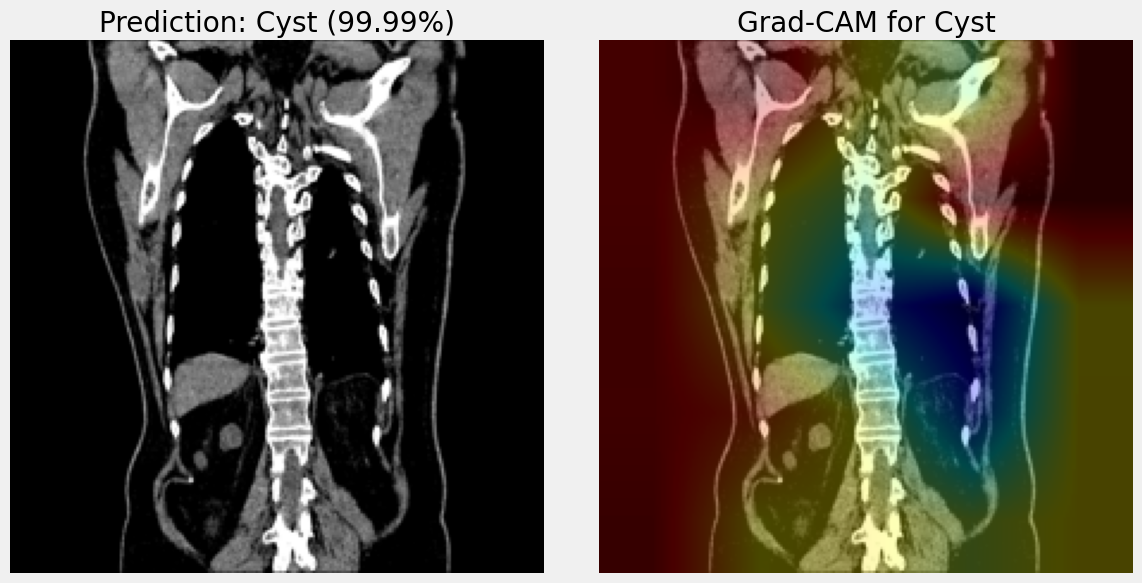

In [31]:
InceptionResNetV2_model.save('kidney_disease_classifier_InceptionResNetV2.keras')

def visualize_grad_cam(model, image_path, class_labels):
  # Import the correct preprocess_input for InceptionResNetV2
  from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input

  # The model is loaded and compiled outside this function, so re-compilation is not needed here.
  # For robustness, if the model wasn't compiled (e.g., if passed directly without loading from file),
  # one might conditionally compile it, but for a loaded model, it's usually already compiled.
  # if not model.optimizer:
  #   model.compile(
  #     optimizer=Adamax(learning_rate=0.01),
  #     loss='categorical_crossentropy',
  #     metrics=['accuracy'])

  image = Image.open(image_path)

  # Preprocess the image before prediction
  img = image.resize((224, 224))
  img_array = tf.keras.preprocessing.image.img_to_array(img)
  original_img = img_array.copy() # Keep a copy of the original for visualization
  img_array = tf.expand_dims(img_array, 0) # Add batch dimension
  preprocessed_img_array = preprocess_input(img_array) # Apply InceptionResNetV2 preprocessing

  # Make Predictions
  predictions = model.predict(preprocessed_img_array)

  # Print the predicted class and confidence
  predicted_class_idx = np.argmax(predictions)
  predicted_class = class_labels[predicted_class_idx]
  confidence = 100 * np.max(predictions) # Calculate confidence for the predicted class

  print(f"Image path: {image_path}")
  print(f"Predicted class: {predicted_class}")
  print(f"Confidence: {confidence:.2f}%")

  print("\nAll class probabilities:")
  for i, prob in enumerate(predictions[0]):
    print(f"  {class_labels[i]}: {100 * prob:.2f}%")

  # --- Grad-CAM Implementation ---
  # 1. Get the base model (InceptionResNetV2) as the feature extractor
  base_model_feature_extractor = model.layers[0] # This is the InceptionResNetV2 functional model

  # The output of this base_model_feature_extractor is the feature map we need.
  # So, the 'last_conv_layer' for Grad-CAM is effectively the output of the base_model_feature_extractor.
  feature_map_output_tensor = base_model_feature_extractor.output
  feature_map_output_shape = base_model_feature_extractor.output_shape

  # Check if the output shape is 4D as required for Grad-CAM
  if not (isinstance(feature_map_output_shape, (tuple, list)) and len(feature_map_output_shape) == 4):
      raise ValueError(f"Output of base model '{base_model_feature_extractor.name}' does not have a 4D shape, which is required for Grad-CAM. Found shape: {feature_map_output_shape}")

  actual_channels = feature_map_output_shape[-1]
  print(f"Using output of base model '{base_model_feature_extractor.name}' for Grad-CAM with {actual_channels} channels.")

  # 2. Create a sub-model that extracts the feature map (which is just the base_model_feature_extractor)
  feature_map_model = tf.keras.Model(
    inputs=base_model_feature_extractor.input,
    outputs=feature_map_output_tensor
  )

  # 3. Create a classifier model that takes the feature map as input and gives the final predictions
  classifier_input = tf.keras.Input(shape=feature_map_output_shape[1:]) # Input shape is the feature map shape
  x = classifier_input
  for layer in model.layers[1:]: # Iterate through layers from GlobalAveragePooling2D onwards
      x = layer(x)
  classifier_model = tf.keras.Model(inputs=classifier_input, outputs=x)

  with tf.GradientTape() as tape:
      # Get the feature map from the feature extractor
      feature_map_output = feature_map_model(preprocessed_img_array)
      # Explicitly watch the feature map output, as it's the source for gradients
      tape.watch(feature_map_output)

      # Pass the watched feature map through the classifier to get predictions
      predictions_from_classifier = classifier_model(feature_map_output)
      class_channel = predictions_from_classifier[:, predicted_class_idx]

  # 4. Gradients of the output neuron with respect to the output feature map of the last conv layer
  grads = tape.gradient(class_channel, feature_map_output)

  # 5. Vector of mean intensity of the gradient over a feature map channel
  pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

  # 6. Multiply each channel in the feature map array by 'how important this channel is' with regard to the top predicted class
  # Use feature_map_output for this calculation
  last_conv_layer_output_for_heatmap = feature_map_output[0]
  heatmap = last_conv_layer_output_for_heatmap @ pooled_grads[..., tf.newaxis]
  heatmap = tf.squeeze(heatmap)

  # 7. For visualization purposes, normalize the heatmap between 0 & 1
  heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
  heatmap = heatmap.numpy()

  # 8. Create a blended image with the original and the heatmap
  # Convert original_img to 0-255 uint8 for cv2
  original_img_uint8 = np.uint8(original_img)
  # Resize heatmap to original image size
  heatmap = cv2.resize(heatmap, (original_img_uint8.shape[1], original_img_uint8.shape[0]))
  heatmap = np.uint8(255 * heatmap)
  # Apply colormap
  heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

  # Superimpose the heatmap on the original image
  superimposed_img = heatmap * 0.4 + original_img_uint8
  superimposed_img = np.uint8(255 * (superimposed_img / np.max(superimposed_img)))

  # Display the image with prediction and confidence and Grad-CAM
  plt.figure(figsize=(12, 6))

  plt.subplot(1, 2, 1)
  plt.imshow(img)
  plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
  plt.axis('off')

  plt.subplot(1, 2, 2)
  plt.imshow(superimposed_img)
  plt.title(f"Grad-CAM for {predicted_class}")
  plt.axis('off')

  plt.tight_layout()
  plt.show()

  return predicted_class, confidence, superimposed_img

# Example usage of the function:
# Load the model (ensure it's compiled or compile it here if necessary)
loaded_model = tf.keras.models.load_model("/content/kidney_disease_classifier_InceptionResNetV2.keras", compile=True)
loaded_model.compile(Adamax(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Define the image path and class labels
image_path_for_test = os.path.join(parent_dir, "Cyst", "Cyst- (1).jpg")
class_labels_for_test = ['Cyst', 'Normal', 'Stone', 'Tumor']

# Call the function
predicted_class, confidence, grad_cam_image = visualize_grad_cam(loaded_model, image_path_for_test, class_labels_for_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Image path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal/Normal- (1).jpg
Predicted class: Normal
Confidence: 98.03%

All class probabilities:
  Cyst: 0.04%
  Normal: 98.03%
  Stone: 1.90%
  Tumor: 0.03%
Using output of base model 'inception_resnet_v2' for Grad-CAM with 1536 channels.


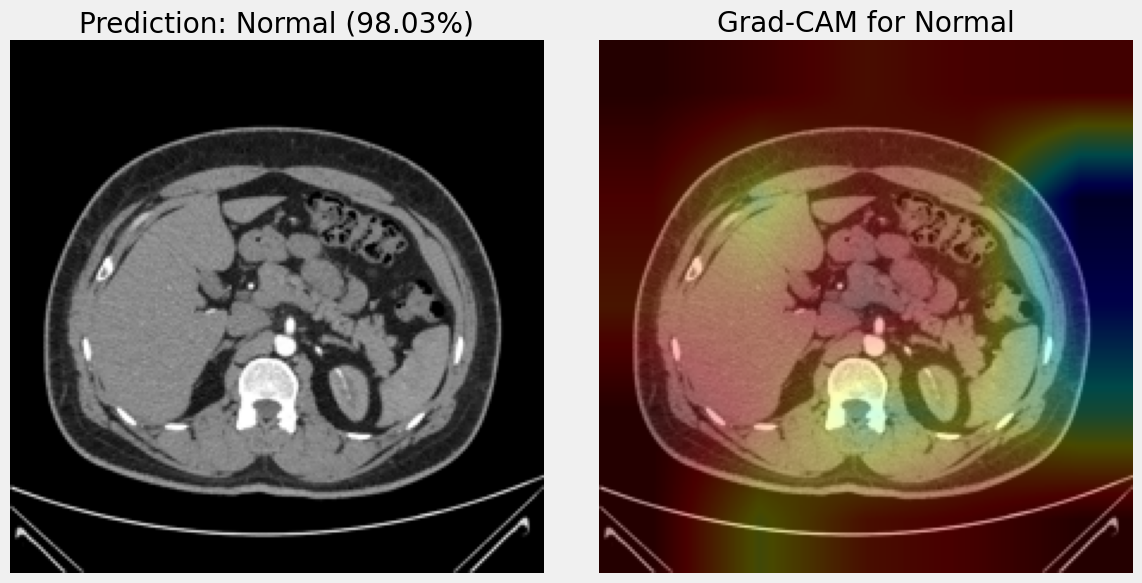

In [34]:
# Example usage of the function:
# Load the model (ensure it's compiled or compile it here if necessary)
loaded_model = tf.keras.models.load_model("/content/kidney_disease_classifier_InceptionResNetV2.keras", compile=True)
loaded_model.compile(Adamax(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Define the image path and class labels
image_path_for_test = os.path.join(parent_dir, "Normal", "Normal- (1).jpg")
class_labels_for_test = ['Cyst', 'Normal', 'Stone', 'Tumor']

# Call the function
predicted_class, confidence, grad_cam_image = visualize_grad_cam(loaded_model, image_path_for_test, class_labels_for_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Image path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Stone/Stone- (100).jpg
Predicted class: Stone
Confidence: 99.85%

All class probabilities:
  Cyst: 0.01%
  Normal: 0.11%
  Stone: 99.85%
  Tumor: 0.02%
Using output of base model 'inception_resnet_v2' for Grad-CAM with 1536 channels.


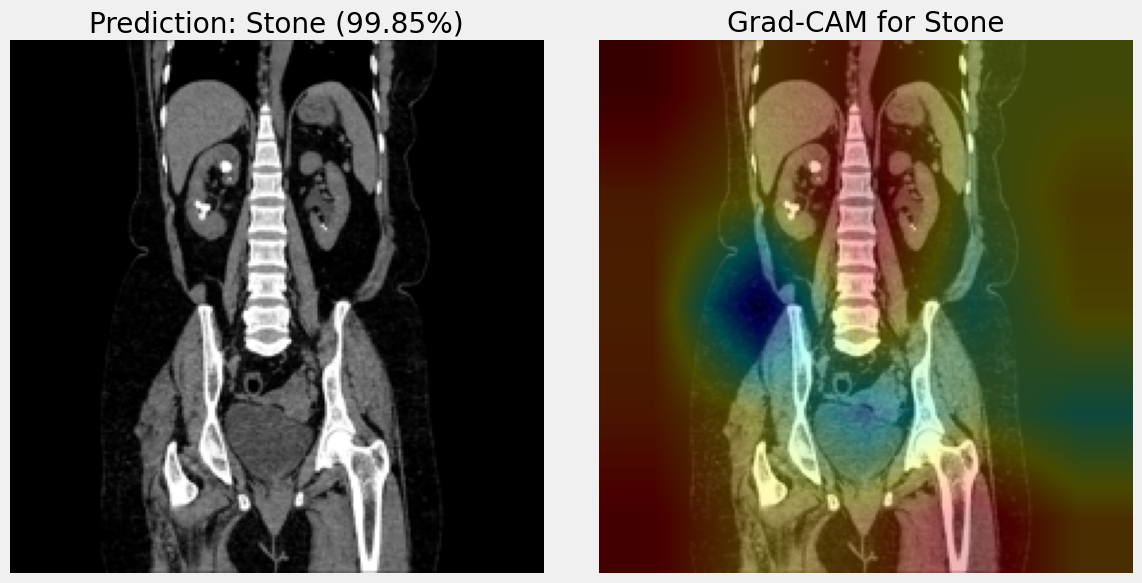

In [36]:
# Example usage of the function:
# Load the model (ensure it's compiled or compile it here if necessary)
loaded_model = tf.keras.models.load_model("/content/kidney_disease_classifier_InceptionResNetV2.keras", compile=True)
loaded_model.compile(Adamax(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Define the image path and class labels
image_path_for_test = os.path.join(parent_dir, "Stone", "Stone- (100).jpg")
class_labels_for_test = ['Cyst', 'Normal', 'Stone', 'Tumor']

# Call the function
predicted_class, confidence, grad_cam_image = visualize_grad_cam(loaded_model, image_path_for_test, class_labels_for_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Image path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Tumor/Tumor- (100).jpg
Predicted class: Tumor
Confidence: 98.76%

All class probabilities:
  Cyst: 0.00%
  Normal: 1.23%
  Stone: 0.00%
  Tumor: 98.76%
Using output of base model 'inception_resnet_v2' for Grad-CAM with 1536 channels.


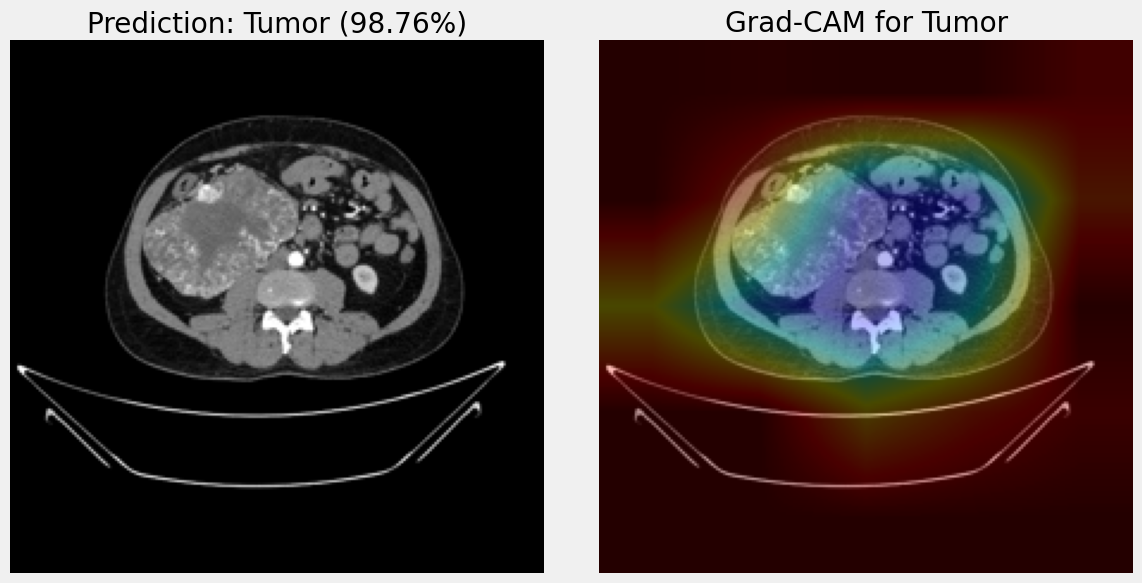

In [37]:
# Example usage of the function:
# Load the model (ensure it's compiled or compile it here if necessary)
loaded_model = tf.keras.models.load_model("/content/kidney_disease_classifier_InceptionResNetV2.keras", compile=True)
loaded_model.compile(Adamax(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])

# Define the image path and class labels
image_path_for_test = os.path.join(parent_dir, "Tumor", "Tumor- (100).jpg")
class_labels_for_test = ['Cyst', 'Normal', 'Stone', 'Tumor']

# Call the function
predicted_class, confidence, grad_cam_image = visualize_grad_cam(loaded_model, image_path_for_test, class_labels_for_test)